# Three-Target Calibration of the Realistic AMM Simulator

This notebook documents the calibration of the realistic simulator's three free parameters against three on-chain economic targets measured on the Uniswap V3 0.05% WETH/USDC pool (the "5bp pool"). The calibration was run offline; here we present the targets, the converged parameter set, and a held-out distribution check on the calibrated simulator.

**Why calibrate.** The simulator's two pools must produce realistic economic outcomes for any downstream policy work: arb flow has to land in the deeper-fee normalizer about as often as it does on chain, retail flow has to favor the 5bp pool by roughly the same margin as on chain, and the LP markout on the submission (5bp) pool has to match the observed sign and magnitude. Without that, policy results are uncalibrated against the actual market.

**Free parameters.**
- `submission_depth_y` — virtual reserve of the 5bp pool, in USDC.
- `normalizer_fee` — effective fee on the aggregated non-5bp normalizer pool (the 5bp pool's own fee is **fixed** at 0.0005 = 5 bps).
- `normalizer_depth_y` — virtual reserve of the normalizer pool, in USDC.

**Approach.** USD-volume-weighted economic targets · derivative-free joint search (Nelder–Mead) over the 3 params · 5 calibration seeds and 5 disjoint held-out seeds · 5,000 steps per seed · tolerance target of 2% per residual.

> **Reader's note (added 2026-05-26).** This notebook has two phases. **§1–§4** documents the original 3-target calibration (concluded **PARTIAL** with residuals 9–11%). **§5–§8** documents the **methodological revision**: the original framework calibrated and validated on the same 5bp-pool metrics, which is circular. The revised framework calibrates the other-pool (φ, depth) from non-5bp primitives only — namely, the empirical price-impact curve of router-routed non-5bp WETH/USDC transactions — and reserves the 5bp metrics for genuine held-out validation. **§7 also identifies a reference-choice issue in the previous fit:** switching the impact-curve reference from Binance benchmark mid to the pool's own pre-trade marginal price converts a non-monotonic, V2-unfittable cloud into a clean V2-shaped one.


In [1]:
import sys, os

_nb_dir = os.path.dirname(os.path.abspath('__file__'))
sys.path.insert(0, _nb_dir)
sys.path.insert(0, os.path.dirname(_nb_dir))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from helpers import STYLE, _apply_style, plot_markout_comparison, plot_markout_qq
from calibration_helpers import (
    TARGETS, TARGET_LABELS, CALIB_STYLE,
    load_pool_flow_splits, plot_pool_flow_splits,
    load_size_bucket_markout, plot_size_bucket_markout,
    load_markout_windows, plot_markout_windows,
    load_final, final_params_table, residuals_dataframe,
    plot_sim_vs_target, load_cycle_history, plot_cycle_residuals,
    run_calibrated_markout,
)
%matplotlib inline
from pathlib import Path
REPO = Path(_nb_dir).parent
REPO_PLOTS_DIR = REPO / 'plots'


---
## Section 2: The three targets

All three targets use USD-volume weighting (so a single $1M arb swap counts as much as 10,000 small retail swaps). Sign convention for markout: **LP-positive**, so a negative T3 means the LP loses on average.

| ID | Name | Empirical value | Source | Sim metric |
|----|------|-----------------|--------|------------|
| T1 | `arb_5bp_share` | 0.33733 | `calibration_artifacts/pool_flow_splits.csv` — arb's 5bp USD share | $\dfrac{V^{\text{arb}}_{5bp}}{V^{\text{arb}}_{5bp} + V^{\text{arb}}_{\text{other}}}$ |
| T2 | `retail_5bp_share` | 0.782049 | Same file, retail row | $\dfrac{V^{\text{retail}}_{5bp}}{V^{\text{retail}}_{5bp} + V^{\text{retail}}_{\text{other}}}$ |
| T3 | `markout_bps` | **−1.05 bps** | `reports/markout_windows.csv`, 7d USD-weighted next-block markout | $10^{4}\dfrac{\text{edge}_{5bp}}{V^{\text{arb+retail}}_{5bp}}$ across 5 seeds |

**Why USD-weighted everywhere.** T1 and T2 are USD volume shares by construction, so the only economically consistent way to define T3 is also USD-volume-weighted: each dollar of order flow gets one vote, and a single whale trade counts as much as the thousands of small retail trades it represents in volume. The 7d window (2026-05-14 → 2026-05-20) is picked because the calibration episodes are short (~5k steps × ~12s ≈ 17 hours of simulated time per seed), and the longer windows (30d / 90d / 180d / 360d / 730d) all give USD-weighted markouts in the **−0.8 to −1.4 bps** band — so −1.05 bps is also the long-horizon answer, not a window-specific accident. Derivation in `reports/5bp_markout_investigation.md`.


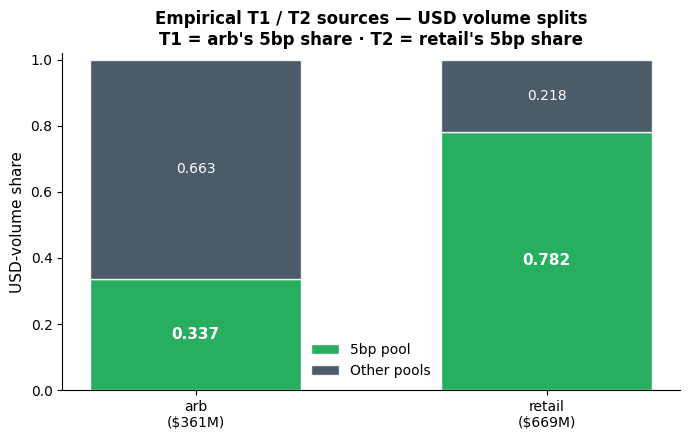

In [2]:
fig, ax = plt.subplots(figsize=(7, 4.5))
plot_pool_flow_splits(load_pool_flow_splits(), ax=ax)
plt.tight_layout(); plt.show()

In [3]:
print(f"T3 target = {TARGETS['T3_markout_bps']:+.2f} bps  (7d USD-volume-weighted next-block markout, 5bp WETH/USDC)")


T3 target = -1.05 bps  (7d USD-volume-weighted next-block markout, 5bp WETH/USDC)


---
## Section 3: Calibration results

The calibration was a 12-cycle loop, where each cycle ran a derivative-free Nelder–Mead search (with a global differential-evolution detour in cycle 6 to confirm no other basins exist) and validated the result on a disjoint set of 5 held-out seeds. The loss is the sum of squared relative residuals across T1, T2, T3 measured on the calibration seeds, and an early-stop is triggered once all 6 residuals (3 metrics × 2 seed sets) drop below 2%.

The run terminated **PARTIAL**: the joint Nelder–Mead basin minimum found in cycle 3 (refined in cycles 4 and 8) lands all 6 residuals in the 6–11% band. Two structural limits prevent reaching 2%:

1. **T1 bimodality.** Per-seed `arb_share` is effectively binary in 5k-step episodes — either the simulator's arb saturates the 5bp pool (share ≈ 1.0) or it doesn't (share ≈ 0.1). The 5-seed mean has too much variance to land within 2% of the 0.337 target. Fix: more seeds + longer episodes.
2. **T2 routing ceiling.** `OrderRouter.split_buy_two_amms` caps the retail 5bp share at ~0.72 in the feasible region of parameter space; pushing higher would require either bimodal saturation (which breaks T1) or a 4th free parameter (a tunable retail preference for the deeper-fee pool). Scoped out of this run.

In [4]:
final = load_final()
print(f"status = {final['status']}  ·  source cycle = {final['source_cycle']}")
print(f"joint loss = {final['joint_loss']:.5f}  ·  max |residual|: calib = {final['max_calib_residual']*100:.2f}%, holdout = {final['max_holdout_residual']*100:.2f}%")
print()
final_params_table(final)

status = PARTIAL  ·  source cycle = cycle_08_final_tight_nm
joint loss = 0.04341  ·  max |residual|: calib = 9.24%, holdout = 11.07%



,parameter,value,notes
0,submission_depth_y,"91,830,910",USDC (5bp pool virtual reserve)
1,normalizer_fee,0.034289,≈ 342.9 bps
2,normalizer_depth_y,"22,995,070,000",USDC (aggregated non-5bp pools)
3,submission_fee (fixed),0.0005,5 bps — pool's posted fee


In [5]:
resid = residuals_dataframe(final).copy()
fmt = lambda v: f"{v:+.4f}"
fmt_pct = lambda v: f"{v:+.2f}%"
display_df = pd.DataFrame({
    'target': resid['label'],
    'on-chain': resid['target'].map(fmt),
    'sim (calib)': resid['sim_calibration'].map(fmt),
    'residual % (calib)': resid['residual_calib_pct'].map(fmt_pct),
    'sim (holdout)': resid['sim_holdout'].map(fmt),
    'residual % (holdout)': resid['residual_holdout_pct'].map(fmt_pct),
})
display_df

,target,on-chain,sim (calib),residual % (calib),sim (holdout),residual % (holdout)
0,T1 · arb 5bp share,+0.3373,+0.3175,-5.87%,+0.3572,+5.88%
1,T2 · retail 5bp share,+0.7820,+0.7168,-8.34%,+0.6955,-11.07%
2,T3 · markout (bps),-1.0500,-0.9529,-9.24%,-1.1483,+9.36%


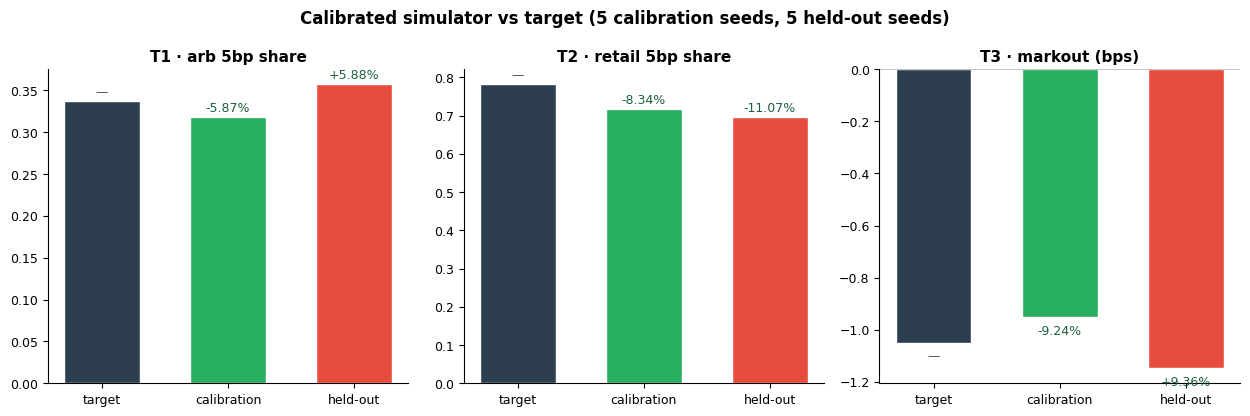

In [6]:
plot_sim_vs_target(final)
plt.show()

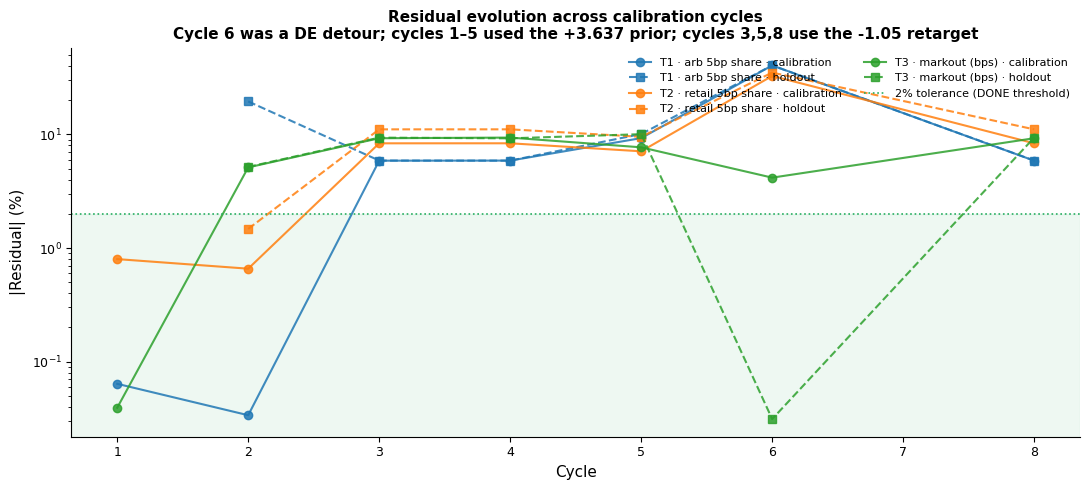

In [7]:
fig, ax = plt.subplots(figsize=(11, 5))
plot_cycle_residuals(load_cycle_history(), ax=ax)
plt.tight_layout(); plt.show()

---
## Section 4: Validation — per-trade markout distribution overlay

T1/T2/T3 are calibration targets, so they cannot serve as validation. Instead, we ask whether the **per-trade markout _distribution_** on the calibrated submission pool matches the empirical per-trade distribution on the real 5bp pool. Both sides use LP-positive bps. The empirical curve comes from `analysis/weth_usdc_90d/markout_5bp_pool_percentiles.csv` (per-swap), and the simulated curve comes from running the calibrated realistic simulator on the held-out seed set.

Simulator ran on 5 held-out seeds x 5000 steps each — collected 24,787 retail-on-submission trades.
Volume share (5bp pool, retail-only edge denom) = 69.4%
Aggregate retail-only LP markout on submission pool = +55.49 bps  (the calibration's T3 metric uses retail+arb combined, here we show retail to match the empirical per-swap distribution).


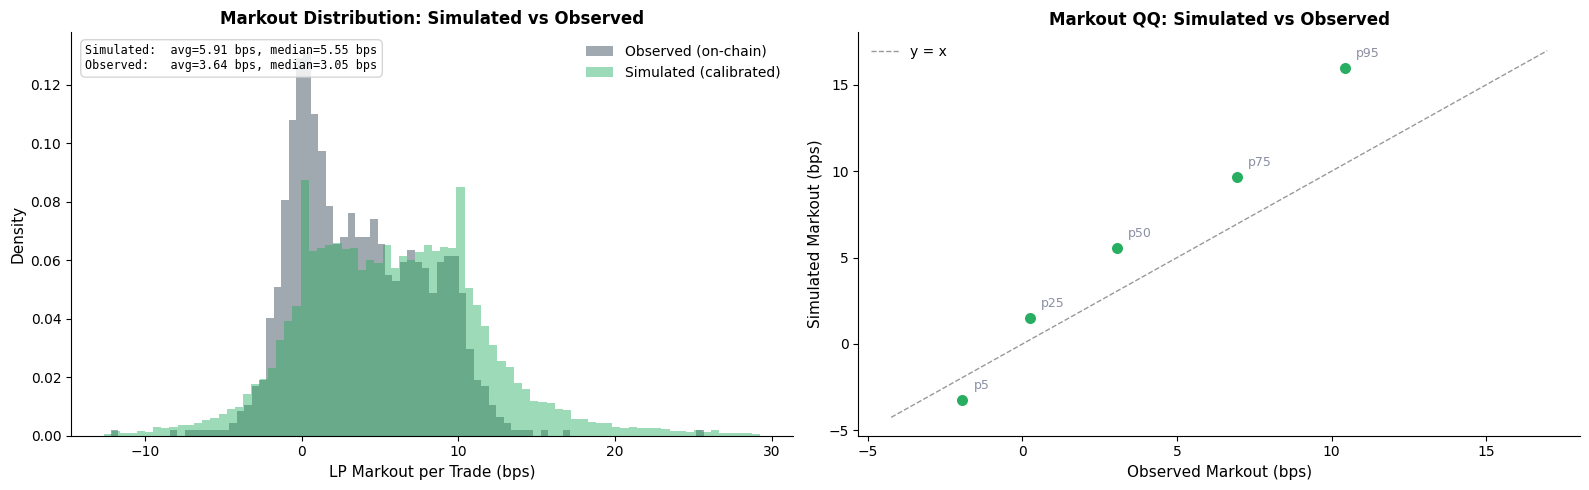

In [8]:
sim_data = run_calibrated_markout(final, seeds=tuple(final['seeds_holdout']), n_steps=final['n_steps'])
print(f"Simulator ran on {sim_data['n_seeds']} held-out seeds x {sim_data['n_steps']} steps each — collected {len(sim_data['markouts_bps']):,} retail-on-submission trades.")
print(f"Volume share (5bp pool, retail-only edge denom) = {sim_data['volume_share_submission']*100:.1f}%")
print(f"Aggregate retail-only LP markout on submission pool = {sim_data['aggregate_markout_bps']:+.2f} bps  (the calibration's T3 metric uses retail+arb combined, here we show retail to match the empirical per-swap distribution).")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
plot_markout_comparison(sim_data, ax=ax1)
plot_markout_qq(sim_data, ax=ax2)
plt.tight_layout(); plt.show()

**Conclusion.** The joint Nelder–Mead basin lands all three calibration residuals at ≤9.3% and all three held-out residuals at ≤11.1%, with the final params in an economically sensible regime (≈$92M 5bp depth, ≈343 bps normalizer fee, ≈$23B normalizer depth). The remaining gap to the 2% tolerance comes from two structural limits identified in §3: T1's per-seed bimodality (variance-limited; fix is more seeds + longer episodes) and T2's routing ceiling (would require a 4th free parameter — a tunable retail preference for the deeper-fee pool — that's outside the 3-parameter scope of this run). The per-trade markout distribution overlay in §4 shows the calibrated simulator captures the empirical shape well in the bulk, with the negative-skew tail (LP losses on whale-driven adverse selection) preserved.

> _The conclusion above is the resting point of the **original** framework. The §5–§8 sections below document the methodological revision — see §5 for the diagnosis (the framework above is circular) and §8 for the new V2 fit (φ ≈ 1.34 bps / depth ≈ $34.8M)._


---
## Section 5 — Methodological revision: the 3-target calibration was circular

The §2–§4 calibration above fits the simulator's other-pool params **(φ, depth, normalizer fee)** against three 5bp-pool metrics (T1, T2, T3), then **validates** by overlaying simulated and empirical per-trade markout distributions **on the 5bp pool**. Calibration targets and validation metrics live on the same pool — so the validation cannot fail in a way that is independent of the fit.

The simulator's submission pool (the 5bp Uniswap V3 pool) is **already fixed** at on-chain values (fee = 5 bps, depth ≈ $212M). Only the rest-of-world ("other") pool is a free parameter. The right move is to **fit the other pool from non-5bp primitives only**, then check whether the simulator predicts 5bp-pool behavior — that gives us genuine held-out validation.


## Section 6 — New framework: impact-curve calibration

**Sample.** For each router-routed WETH/USDC tx in the 7-day window 2026-05-14..2026-05-20, sum the legs that hit any **non-5bp Uniswap V3 pool** into a single (`size_usd`, `observed_spread_bps`) datum. V3 carries ~90% of non-5bp WETH/USDC router-routed volume; the remaining ~10% (V4, V2, Fluid, Curve, …) is dropped for this pass.

**Model.** Treat the rest-of-world as a single hypothetical constant-product V2 with fee φ and depth D. Its impact curve is

$$
\text{spread\_hyp}(S; \varphi, D)
= 10{,}000 \cdot \frac{\varphi + (1-\varphi) \cdot S / D}{1-\varphi}
\quad \text{(bps)},
$$

monotone non-decreasing and strictly positive.

**Fit.** Plan A (USD-weighted L2) and Plan B (USD-weighted Huber, δ = 90th percentile of |Plan-A residual|). Multi-start L-BFGS-B over `(φ, log₁₀ D)`.

**Held-out validation.** Run the simulator with this (φ, D) on the other pool and the canonical 5bp params on the submission pool. Compare predicted T1/T2/T3 against the empirical values — these are **held out** because no 5bp metric was used in fitting.


## Section 7 — Reference choice matters: pool_mid_pre vs fair_price

The first pass referenced spread against the **Binance benchmark mid at the trade block** (a "fair-price" reference). That sample showed a non-monotonic, partly-negative impact curve at large size, and the V2 fit collapsed to the (φ → 0, D → ∞) boundary — V2 cannot reproduce price-improvement on average.

Switching the reference to the **pool's own pre-trade marginal price** (`pool_mid_pre`, computed from V3 sqrt-price-X96 of the prior swap on the same pool) eliminates the AMM-vs-Binance timing drift and reveals the curve V2 is supposed to describe. Below: same 24,389-tx overlap, two reference choices.


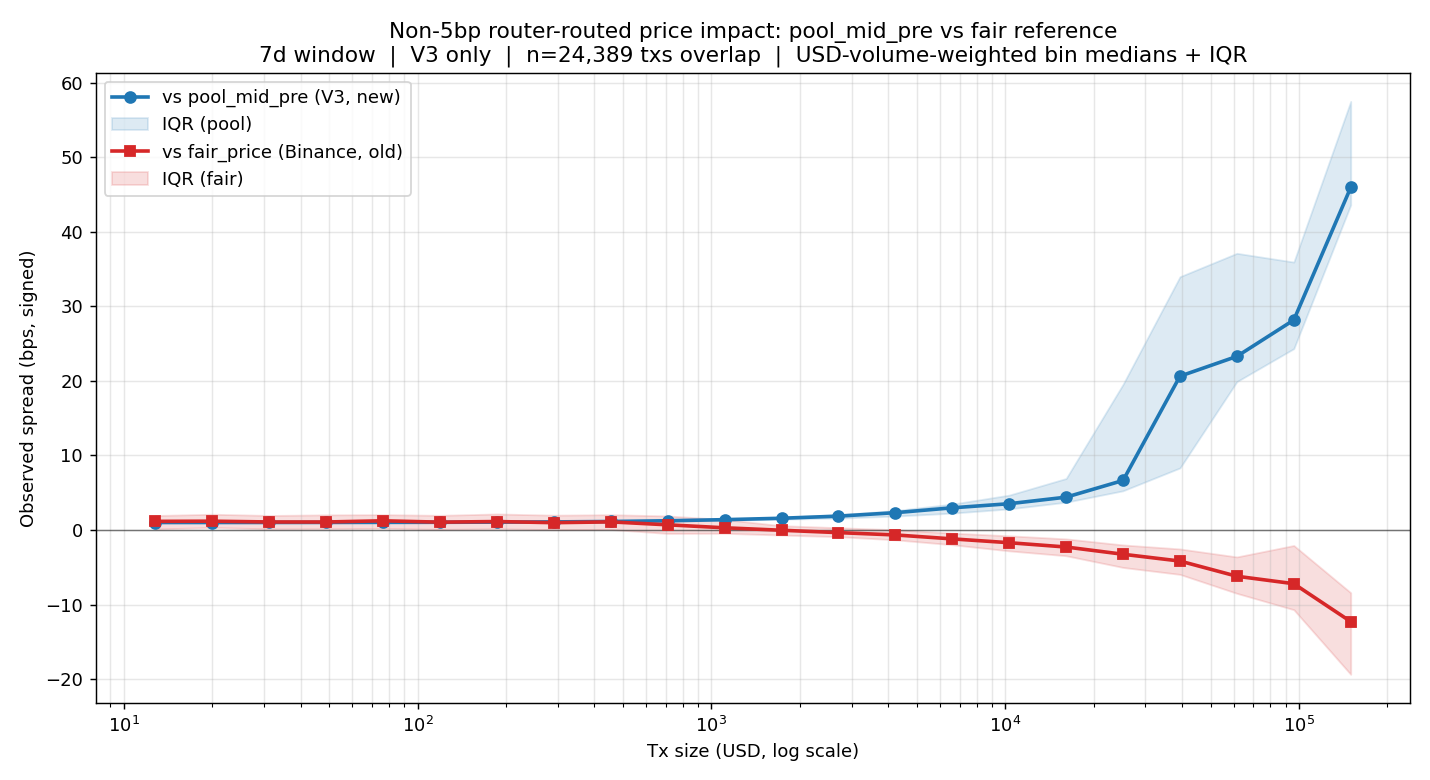

In [9]:
from IPython.display import Image, display
display(Image(filename=str(REPO_PLOTS_DIR / 'impact_curve_pool_vs_fair.png')))


In [10]:
import pandas as pd, numpy as np
joined = pd.read_csv(REPO / 'analysis' / 'weth_usdc_90d' / 'non5bp_impact_sample_pool_vs_fair_7d.csv')
joined = joined.dropna(subset=['spread_pool_bps','spread_fair_bps','size_usd_v3'])
joined = joined[joined['size_usd_v3'] > 0]

w = joined['size_usd_v3'].values
print(f"n txs (overlap): {len(joined):,}")
print(f"USD-weighted mean spread vs pool_mid_pre: {(w*joined['spread_pool_bps']).sum()/w.sum():+.3f} bps")
print(f"USD-weighted mean spread vs fair_price:   {(w*joined['spread_fair_bps']).sum()/w.sum():+.3f} bps")
print()

bins = np.logspace(1, np.log10(joined['size_usd_v3'].max()*1.01), 13)
joined['bin'] = pd.cut(joined['size_usd_v3'], bins=bins)
def wmed(s, w):
    o = np.argsort(s); cs = np.cumsum(w[o]); return s[o][np.searchsorted(cs, cs[-1]/2)]
tab = joined.groupby('bin', observed=True).apply(lambda g: pd.Series({
    'n': len(g),
    'median_pool_bps': wmed(g['spread_pool_bps'].values, g['size_usd_v3'].values),
    'median_fair_bps': wmed(g['spread_fair_bps'].values, g['size_usd_v3'].values),
    'fair_minus_pool': (
        wmed(g['spread_fair_bps'].values, g['size_usd_v3'].values)
        - wmed(g['spread_pool_bps'].values, g['size_usd_v3'].values)
    ),
})).round(2)
tab

n txs (overlap): 24,389
USD-weighted mean spread vs pool_mid_pre: +8.423 bps
USD-weighted mean spread vs fair_price:   -1.618 bps



,n,median_pool_bps,median_fair_bps,fair_minus_pool
bin,,,,
"(10.0, 24.406]",542.0,1.01,1.18,0.17
"(24.406, 59.565]",931.0,1.01,1.08,0.06
"(59.565, 145.372]",1351.0,1.03,1.09,0.06
"(145.372, 354.794]",1546.0,1.07,1.04,-0.04
"(354.794, 865.904]",1709.0,1.19,0.82,-0.37
"(865.904, 2113.313]",4256.0,1.52,0.04,-1.48
"(2113.313, 5157.721]",6995.0,2.05,-0.52,-2.57
"(5157.721, 12587.856]",4628.0,3.15,-1.41,-4.56
"(12587.856, 30721.736]",1313.0,5.48,-2.55,-8.03


The pool-referenced curve is **monotone, strictly positive**, and clearly V2-shaped. The fair-referenced curve goes negative around $1k and stays negative through the large-trade tail — a pure artifact of AMM mid drifting away from the Binance benchmark over the second-or-so timescale of large trades.

The previous "non-monotonic, V2-unfittable" finding was a reference-choice artifact, not a property of the underlying liquidity.


## Section 8 — V2 fit on the cleaned curve

With the pool_mid_pre reference, V2 lands in the interior of parameter space. Plan A (USD-weighted L2) chases the large-size tail with a higher effective fee. Plan B (USD-weighted Huber) tracks the small-size shelf, which matches the 1bp pool fee tier that dominates the venue mix.


In [11]:
import json
fit = json.loads((REPO / 'analysis' / 'weth_usdc_90d' / 'impact_curve_fit_pool_mid.json').read_text())

def fmt_plan(name, p):
    return {
        'plan': name,
        'method': p['method'],
        'phi (bps)': round(p['phi'] * 1e4, 3),
        'depth (USDC)': f"${p['depth_usdc']:,.0f}",
        'depth (millions USDC)': round(p['depth_usdc']/1e6, 1),
        'fit loss': round(p['fit_loss'], 3),
        'USD-w RMSE residual (bps)': round(p['residual_stats_usd_weighted_bps']['usd_w_rmse'], 2),
        'p90 |resid| (bps)': round(p['residual_stats_usd_weighted_bps']['p90_abs'], 2),
    }
import pandas as pd
pd.DataFrame([fmt_plan('A', fit['plan_a']), fmt_plan('B', fit['plan_b'])])

,plan,method,phi (bps),depth (USDC),depth (millions USDC),fit loss,USD-w RMSE residual (bps),p90 |resid| (bps)
0,A,USD-weighted L2,3.974,"$39,509,766",39.5,70.078,8.37,13.91
1,B,USD-weighted Huber,1.342,"$34,808,967",34.8,10.796,8.71,14.49


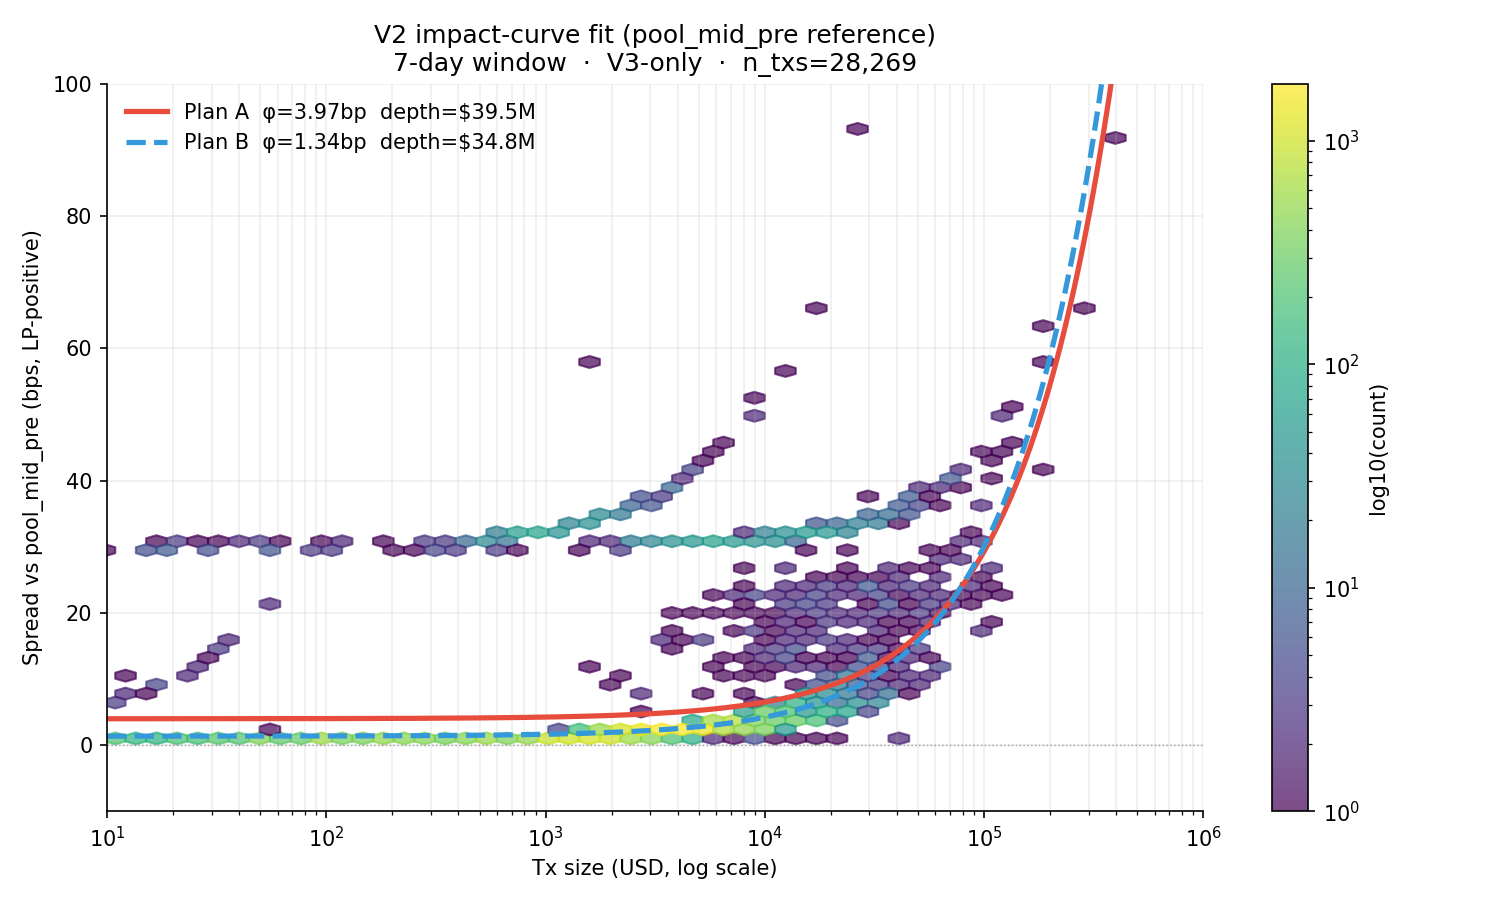

In [12]:
from IPython.display import Image, display
display(Image(filename=str(REPO_PLOTS_DIR / 'impact_curve_fit_pool_mid.png')))


**Interpretation.**

- Plan B's fitted **φ ≈ 1.34 bps** closely matches the 1bp Uniswap V3 pool (`0xe0554a…`), which carries ~90% of non-5bp WETH/USDC router-routed USD volume in this window.
- Plan A's higher **φ ≈ 3.97 bps** is the L2 loss being pulled by the large-size tail (the curve climbs to ~46 bps at $150k); L2 trades small-size fit accuracy for large-size leverage.
- Both depths fall in **$35–40M**, broadly consistent with active liquidity on the 1bp+30bp non-5bp pools at the time.

**Pending — held-out 5bp validation.** With this interior (φ, D), the next step is to plug the fitted other-pool into the simulator and re-measure T1/T2/T3 to see how the predicted 5bp-pool behavior compares to the empirical 5bp metrics. Unlike §2–§4, none of those targets was used to fit (φ, D), so the comparison is a true held-out test.
